In [1]:
import json, random, warnings, sys, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from copy import deepcopy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
warnings.filterwarnings("ignore")

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TRAIN_CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/2025_02_Security/03_Data/train.csv"
TEST_CSV_PATH  = "/content/drive/MyDrive/Colab Notebooks/2025_02_Security/03_Data/testcase.csv"

In [6]:
MIN_PKTS = 10
MAX_LEN = 128
BATCH = 64
EPOCHS = 120
LR = 3e-4

In [7]:
def robust_read_csv(path):
    import csv as _csv
    try:
        _csv.field_size_limit(sys.maxsize)
    except Exception:
        pass
    return pd.read_csv(path, engine="python", quotechar='"', escapechar='\\', on_bad_lines="skip")

In [8]:
def three_channel(len_str, dir_str, time_str):
    """
    패킷 길이/방향/시간 시퀀스를 3채널 [L, 3]로 만들고,
    IAT, flow duration 등 풍부한 flow-level 통계 feature도 같이 반환.
    """
    L_raw = np.array(json.loads(len_str), dtype=float)
    D_raw = np.array(json.loads(dir_str), dtype=float)
    T_raw = np.array(json.loads(time_str), dtype=float)

    # 세 시퀀스 길이 맞추기
    n = min(len(L_raw), len(D_raw), len(T_raw))

    if n == 0:
        # 방어 코드
        L = np.zeros((1,), dtype=float)
        D = np.zeros((1,), dtype=float)
        T = np.zeros((1,), dtype=float)
        n = 1
    else:
        L = L_raw[:n]
        D = D_raw[:n]
        T = T_raw[:n]

    # --- 1) per-packet feature 구성 ---

    # length: log1p + 부호 유지
    L_log = np.log1p(np.abs(L)) * np.sign(L)

    # direction: 그대로 (예: +1/-1)
    D_ch = D

    # time: 절대시간 대신 inter-arrival time(IAT)
    if len(T) > 1:
        iat = np.diff(T, prepend=T[0])   # 첫 번째는 0 또는 아주 작은 값
    else:
        iat = np.zeros_like(T)
    iat = np.clip(iat, a_min=0, a_max=None)
    IAT_log = np.log1p(iat)

    # --- 2) flow-level 통계 feature ---

    L_abs = np.abs(L)
    n_pkts = float(n)
    duration = float(T[-1] - T[0]) if n > 1 else 0.0

    # 방향 전환 비율 (up->down, down->up)
    if n > 1:
        dir_changes = np.sum(D[:-1] * D[1:] < 0)
        dir_change_ratio = dir_changes / (n - 1)
    else:
        dir_change_ratio = 0.0

    # IAT 통계
    iat_mean = float(np.mean(iat)) if n > 1 else 0.0
    iat_std  = float(np.std(iat))  if n > 1 else 0.0
    iat_max  = float(np.max(iat))  if n > 1 else 0.0

    # 업스트림/다운스트림 bytes
    up_bytes   = float(np.sum(L_abs[D > 0]))
    down_bytes = float(np.sum(L_abs[D < 0]))

    stats = np.array([
        # length 관련
        float(np.mean(L_log)),        # 0: 평균 길이 (로그)
        float(np.std(L_log)),         # 1: 길이 표준편차
        float(np.sum(L_abs)),         # 2: 전체 길이 합

        # direction 관련
        float(np.mean(D_ch)),         # 3: 방향 평균
        float(np.mean(D_ch > 0)),     # 4: 양의 방향 비율
        float(dir_change_ratio),      # 5: 방향 전환 비율

        # IAT/시간 관련
        float(np.log1p(iat_mean)),    # 6: IAT 평균 (log)
        float(np.log1p(iat_std)),     # 7: IAT 표준편차 (log)
        float(np.log1p(iat_max)),     # 8: IAT 최대값 (log)
        float(np.log1p(duration)),    # 9: flow duration (log)

        # 패킷 수 / 상하향 bytes
        float(np.log1p(n_pkts)),      # 10: 패킷 수 (log)
        float(np.log1p(up_bytes)),    # 11: upstream bytes (log)
        float(np.log1p(down_bytes)),  # 12: downstream bytes (log)
    ], dtype=np.float32)              # → stats_dim = 13

    # --- 3) padding ---

    def pad(v):
        return v[:MAX_LEN] if len(v) >= MAX_LEN else np.pad(v, (0, MAX_LEN - len(v)))

    L_pad   = pad(L_log)
    D_pad   = pad(D_ch)
    IAT_pad = pad(IAT_log)

    X = np.stack([L_pad, D_pad, IAT_pad], axis=-1)  # [L, 3]

    pad_mask = (np.arange(MAX_LEN) >= n)

    return X.astype(np.float32), pad_mask.astype(bool), stats

In [9]:
class FlowDataset(Dataset):
    def __init__(self, df, le):
        self.items = []
        y = le.transform(df["label"].values)

        for ls, ds, ts, yy in tqdm(
            zip(
                df["length_sequence"],
                df["direction_sequence"],
                df["time_sequence"],   # ★ time 시퀀스 컬럼
                y,
            ),
            desc="flowdataset init",
            total=len(df),
        ):
            feat, mask, stats = three_channel(ls, ds, ts)
            self.items.append((feat, mask, stats, yy))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        x, m, s, y = self.items[i]
        return (
            torch.from_numpy(x),        # [L, 3]
            torch.from_numpy(m),
            torch.from_numpy(s),
            torch.tensor(y, dtype=torch.long),
        )

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(1))  # [L,1,D]

    def forward(self, x):  # x: [L,B,D]
        L = x.size(0)
        return x + self.pe[:L]

In [11]:
class FlowTransformer(nn.Module):
    def __init__(
        self,
        num_classes,
        d_model=192,
        n_heads=8,
        num_layers=4,
        ff=384,
        p=0.20,
        stats_dim=13,
    ):
        super().__init__()
        self.proj = nn.Linear(3, d_model)
        self.pe = PositionalEncoding(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model,
            n_heads,
            ff,
            dropout=p,
            activation="gelu",
            batch_first=False,
            norm_first=True  # ★ Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # ★ Attention pooling 추가
        self.attn_pool = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        self.stats_proj = nn.Sequential(
            nn.Linear(stats_dim, d_model),
            nn.GELU(),
            nn.Dropout(p * 0.5),  # stats는 dropout 적게
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
        )

        self.drop = nn.Dropout(p)

        # ★ 3가지 representation 결합 (CLS + Attention + Stats)
        self.fc = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(p),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, stats, key_padding_mask=None):
        B, L, _ = x.shape

        x = self.proj(x)
        x = x.permute(1, 0, 2)

        # CLS 토큰
        cls = self.cls_token.expand(-1, B, -1)
        x = torch.cat([cls, x], dim=0)

        if key_padding_mask is not None:
            pad = torch.zeros(B, 1, dtype=key_padding_mask.dtype, device=key_padding_mask.device)
            key_padding_mask = torch.cat([pad, key_padding_mask], dim=1)

        x = self.pe(x)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        # ★ CLS 토큰 출력
        cls_out = x[0]

        # ★ Attention pooling (sequence 전체 활용)
        query = self.query.expand(B, -1, -1)
        seq = x[1:].permute(1, 0, 2)  # [B, L, D]
        attn_out, _ = self.attn_pool(query, seq, seq,
                                      key_padding_mask=key_padding_mask[:, 1:] if key_padding_mask is not None else None)
        attn_out = attn_out.squeeze(1)

        # ★ Stats embedding
        stats_emb = self.stats_proj(stats)

        # ★ 3가지 결합
        h = torch.cat([cls_out, attn_out, stats_emb], dim=-1)
        h = self.drop(h)
        out = self.fc(h)
        return out

In [12]:
# 기존 CrossEntropy + FocalLoss 혼합을 위한 준비
class FocalLoss(nn.Module):
  def __init__(self, alpha=1.0, gamma=2.0, weight=None, reduction='mean'):
    super().__init__()
    self.alpha = alpha
    self.gamma = gamma
    self.weight = weight
    self.reduction = reduction


  def forward(self, input, target):
    ce = nn.functional.cross_entropy(input, target, weight=self.weight, reduction='none')
    pt = torch.exp(-ce)
    focal = self.alpha * (1 - pt) ** self.gamma * ce
    return focal.mean() if self.reduction == 'mean' else focal.sum()


def hybrid_loss_fn(logits, targets, alpha=0.6):
  loss_focal = focal_loss(logits, targets)
  loss_smooth = smooth_ce(logits, targets)
  return alpha * loss_focal + (1 - alpha) * loss_smooth

In [13]:
def train_epochs(
    model,
    tr_ld,
    te_ld,
    opt,
    scheduler,
    start_epoch,
    num_epochs,
    best_f1,
    best_state,
    desc="Fitting TF",
    history=None,   # 로그 저장용
):
    n_train = len(tr_ld.dataset)
    n_val   = len(te_ld.dataset)

    for e in tqdm(range(start_epoch, start_epoch + num_epochs), desc=desc):
        # -------------------
        # Train
        # -------------------
        model.train()
        tot_loss = 0.0
        tr_yp, tr_yt = [], []   # ★ train F1 계산용

        for x, m, s, y in tr_ld:
            x, m, s, y = x.to(DEVICE), m.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
            out = model(x, s, key_padding_mask=m)
            loss = hybrid_loss_fn(out, y)

            opt.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tot_loss += loss.item() * x.size(0)

            # ★ train F1 위해 예측/정답 저장
            tr_yp.append(out.argmax(1).detach().cpu().numpy())
            tr_yt.append(y.detach().cpu().numpy())

        train_loss = tot_loss / n_train
        tr_yp = np.concatenate(tr_yp)
        tr_yt = np.concatenate(tr_yt)
        train_f1 = f1_score(tr_yt, tr_yp, average="macro")

        # -------------------
        # Validation
        # -------------------
        model.eval()
        val_loss_tot = 0.0
        yp_val, yt_val = [], []

        with torch.no_grad():
            for x, m, s, y in te_ld:
                x, m, s, y = x.to(DEVICE), m.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
                out = model(x, s, key_padding_mask=m)

                # ★ validation loss도 같은 hybrid loss로 계산
                loss = hybrid_loss_fn(out, y)
                val_loss_tot += loss.item() * x.size(0)

                yp_val.append(out.argmax(1).cpu().numpy())
                yt_val.append(y.cpu().numpy())

        val_loss = val_loss_tot / n_val
        yp_val = np.concatenate(yp_val)
        yt_val = np.concatenate(yt_val)
        val_f1 = f1_score(yt_val, yp_val, average="macro")

        # LR 스케줄러는 val F1 기준
        scheduler.step(val_f1)

        # -------------------
        # best 갱신 + history 기록
        # -------------------
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = deepcopy(model.state_dict())

        if history is not None:
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_f1"].append(train_f1)
            history["val_f1"].append(val_f1)

        if (e % 5 == 0) or (e == start_epoch):
            print(
                f"Epoch {e:03d}: "
                f"train_loss={train_loss:.4f}, "
                f"val_loss={val_loss:.4f}, "
                f"train_macro_f1={train_f1:.4f}, "
                f"val_macro_f1={val_f1:.4f}, "
                f"best_macro_f1={best_f1:.4f}"
            )

    return best_f1, best_state

In [14]:
class FlowDatasetInfer(Dataset):
    def __init__(self, df):
        self.items = []
        for ls, ds, ts in tqdm(
            zip(
                df["length_sequence"],
                df["direction_sequence"],
                df["time_sequence"],
            ),
            desc="flowdataset infer init",
            total=len(df),
        ):
            feat, mask, stats = three_channel(ls, ds, ts)
            self.items.append((feat, mask, stats))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        x, m, s = self.items[i]
        return (
            torch.from_numpy(x),
            torch.from_numpy(m),
            torch.from_numpy(s),
        )

In [15]:
# --- main ---
# 1) train.csv 로드 (라벨 있음)
df = robust_read_csv(TRAIN_CSV_PATH)
req = {"length_sequence", "direction_sequence", "time_sequence", "num_packets", "label"}
assert req.issubset(df.columns)
df = df[df["num_packets"].astype(int) > MIN_PKTS].reset_index(drop=True)

# 2) test.csv 로드 (라벨 없다고 가정, 나중에 추론용으로만 사용)
df_test = robust_read_csv(TEST_CSV_PATH)
df_test = df_test[df_test["num_packets"].astype(int) > MIN_PKTS].reset_index(drop=True)

In [16]:
print(df.shape, df_test.shape)
print(df.columns)
print(df_test.columns)

(29264, 10) (229, 9)
Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'num_packets',
       'time_sequence', 'length_sequence', 'direction_sequence', 'label'],
      dtype='object')
Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'num_packets',
       'time_sequence', 'length_sequence', 'direction_sequence'],
      dtype='object')


In [17]:
# 3) 라벨 인코더: train 기준으로 학습
le = LabelEncoder()
le.fit(df["label"].values)

# 4) train 데이터를 9:1로 train/validation 분할
groups = df["from"].values if "from" in df.columns else np.arange(len(df))
gss = GroupShuffleSplit(test_size=0.1, random_state=SEED)  # ★ 9:1
tr_idx, val_idx = next(gss.split(df, df["label"].values, groups=groups))

dtr = df.iloc[tr_idx].reset_index(drop=True)   # 90% → train
dte = df.iloc[val_idx].reset_index(drop=True)  # 10% → validation

In [18]:
def collate(batch):
    xs, ms, ss, ys = zip(*batch)
    xs = torch.stack(xs)                  # [B,L,3]
    ms = torch.stack(ms).bool()           # [B,L]
    ss = torch.stack(ss)                  # [B,stats_dim]
    ys = torch.tensor(ys, dtype=torch.long)
    return xs, ms, ss, ys

# 5) Dataset / DataLoader
tr_ds = FlowDataset(dtr, le)
te_ds = FlowDataset(dte, le)   # 여기서는 validation set

tr_ld = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate)
te_ld = DataLoader(te_ds, batch_size=BATCH, shuffle=False, collate_fn=collate)

flowdataset init: 100%|██████████| 2927/2927 [00:02<00:00, 1383.40it/s]


In [19]:
# 모델 용량 살짝 업: d_model=192, ff=384, dropout=0.2
model = FlowTransformer(
    num_classes=len(le.classes_),
    d_model=192,
    ff=384,
    p=0.20,          # dropout
).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

In [20]:
# --- class weight 계산 (macro F1 개선용) ---
# dtr은 train용 dataframe (train/val 9:1 중 train 부분)
label_list = dtr["label"].values
cnt = Counter(label_list)

# 각 원래 라벨 이름 기준으로 빈도 카운트
labels = sorted(cnt.keys())
freqs = np.array([cnt[l] for l in labels], dtype=np.float32)

# "전체 / (클래스수 * 각 빈도)" 형태로 역비율 weight
class_weight_raw = (len(label_list) / (len(labels) * freqs))

# LabelEncoder 인덱스 순서로 weight 매핑
weight_per_idx = np.zeros(len(le.classes_), dtype=np.float32)
for lab, w in zip(labels, class_weight_raw):
    idx = le.transform([lab])[0]
    weight_per_idx[idx] = w

weight_tensor = torch.tensor(weight_per_idx, dtype=torch.float32, device=DEVICE)
# FocalLoss와 CrossEntropyLoss 조합으로 loss 구성
focal_loss = FocalLoss(gamma=2.0, weight=weight_tensor)
smooth_ce = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.02)

# LR 스케줄러: val macro F1 기준으로 plateau 시 LR 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="max",
    factor=0.5,
    patience=3,
)

In [21]:
# --- history for plotting ---
history = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": [],
}

In [22]:
best_f1 = 0.0
best_state = None

best_f1, best_state = train_epochs(
    model, tr_ld, te_ld, opt, scheduler,
    start_epoch=1,
    num_epochs=EPOCHS,
    best_f1=best_f1,
    best_state=best_state,
    desc="Fitting TF (main)",
    history=history,
)

Fitting TF (main):   1%|          | 1/120 [00:24<48:59, 24.70s/it]

Epoch 001: train_loss=3.8403, val_loss=2.9782, train_macro_f1=0.0681, val_macro_f1=0.1791, best_macro_f1=0.1791


Fitting TF (main):   4%|▍         | 5/120 [02:01<46:56, 24.49s/it]

Epoch 005: train_loss=1.2948, val_loss=1.1647, train_macro_f1=0.6150, val_macro_f1=0.6666, best_macro_f1=0.6666


Fitting TF (main):   8%|▊         | 10/120 [04:04<45:04, 24.59s/it]

...

Epoch 110: train_loss=0.2128, val_loss=0.4204, train_macro_f1=0.9557, val_macro_f1=0.9069, best_macro_f1=0.9104


Fitting TF (main):  96%|█████████▌| 115/120 [47:14<02:03, 24.60s/it]

Epoch 115: train_loss=0.2126, val_loss=0.4204, train_macro_f1=0.9552, val_macro_f1=0.9069, best_macro_f1=0.9104


Fitting TF (main): 100%|██████████| 120/120 [49:16<00:00, 24.64s/it]

Epoch 120: train_loss=0.2141, val_loss=0.4204, train_macro_f1=0.9542, val_macro_f1=0.9069, best_macro_f1=0.9104


In [23]:
def collate_infer(batch):
    xs, ms, ss = zip(*batch)
    xs = torch.stack(xs)         # [B,L,3]
    ms = torch.stack(ms).bool()  # [B,L]
    ss = torch.stack(ss)         # [B,stats_dim]
    return xs, ms, ss

test_ds = FlowDatasetInfer(df_test)
test_ld = DataLoader(test_ds, batch_size=BATCH, shuffle=False, collate_fn=collate_infer)

flowdataset infer init: 100%|██████████| 229/229 [00:00<00:00, 2029.25it/s]


In [24]:
# --- Validation 평가 ---
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\n[Best model loaded] tracked val macro F1 = {best_f1:.4f}")
else:
    print("\n[Warning] best_state is None, using last model parameters.")

model.eval()

# 1) Validation set F1-score 계산
yp, yt = [], []
with torch.no_grad():
    for x, m, s, y in te_ld:   # te_ld = validation DataLoader
        x, m, s, y = x.to(DEVICE), m.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
        out = model(x, s, key_padding_mask=m)
        yp.append(out.argmax(1).cpu().numpy())
        yt.append(y.cpu().numpy())

yp = np.concatenate(yp)
yt = np.concatenate(yt)


[Best model loaded] tracked val macro F1 = 0.9104


In [25]:
print("\n[Validation F1-Score]")
print("  Macro   =", f1_score(yt, yp, average="macro"))
print("  Micro   =", f1_score(yt, yp, average="micro"))
print("  Weighted=", f1_score(yt, yp, average="weighted"))


[Validation F1-Score]
  Macro   = 0.9103844323825985
  Micro   = 0.909805261359754
  Weighted= 0.9093325870586245


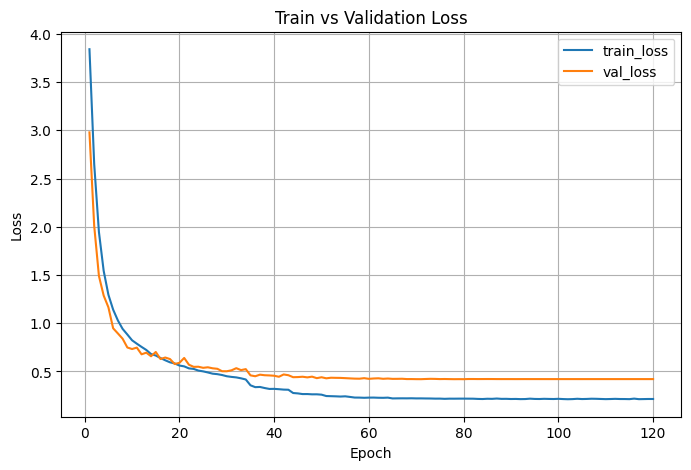

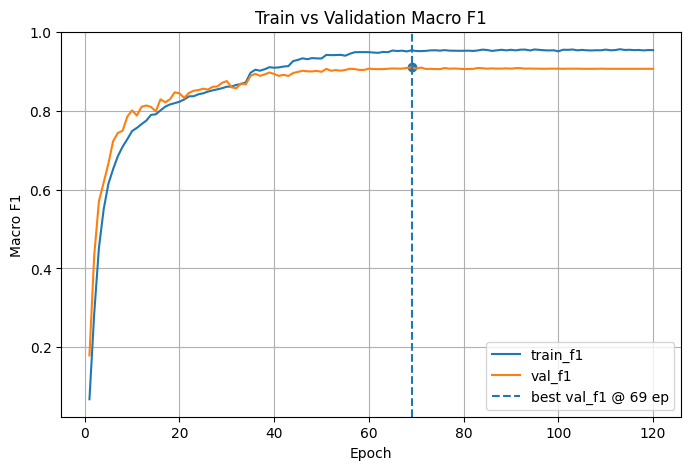

Best val_f1 (from history) = 0.9104 at epoch 69


In [26]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

# 1) Loss 곡선
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2) Macro F1 곡선
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], label="train_f1")
plt.plot(epochs, history["val_f1"], label="val_f1")

# ★ early stopping 후보: val_f1 최대인 epoch
best_epoch = int(np.argmax(history["val_f1"])) + 1
best_val_f1 = history["val_f1"][best_epoch - 1]

plt.axvline(best_epoch, linestyle="--", label=f"best val_f1 @ {best_epoch} ep")
plt.scatter([best_epoch], [best_val_f1])

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Train vs Validation Macro F1")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best val_f1 (from history) = {best_val_f1:.4f} at epoch {best_epoch}")

In [27]:
# --- 클래스별 리포트 ---
class_ids = np.unique(yt)  # 실제 validation에 등장한 클래스 id들
target_names = [
    str(le.inverse_transform([cid])[0])   # id → 원래 라벨 (문자열)
    for cid in class_ids
]

print("\n[Per-class classification report]")
print(classification_report(
    yt,
    yp,
    labels=class_ids,
    target_names=target_names,
    zero_division=0,
))


[Per-class classification report]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        44
           1       0.91      0.87      0.89        46
           2       0.97      0.95      0.96        39
           3       0.98      0.90      0.94        51
           4       0.98      1.00      0.99        40
           5       0.87      0.98      0.92        42
           6       0.90      0.93      0.91        28
           7       0.98      0.96      0.97        46
           8       0.91      0.94      0.93        33
           9       1.00      0.94      0.97        36
          10       0.95      0.98      0.96        41
          11       1.00      1.00      1.00        37
          12       0.97      0.97      0.97        33
          13       0.85      0.93      0.89        44
          14       1.00      1.00      1.00        35
          15       0.92      1.00      0.96        35
          16       0.93      0.96      0.94   


[Top F1 classes]
    class_id label        f1  support
11        11    11  1.000000       37
51        51    51  1.000000       37
66        66    66  1.000000       39
14        14    14  1.000000       35
17        17    17  0.987952       41
4          4     4  0.987654       40
46        46    46  0.986667       37
55        55    55  0.985075       33
62        62    62  0.983607       31
24        24    24  0.981132       26

[Bottom F1 classes]
    class_id label        f1  support
76        76    76  0.694444       39
59        59    59  0.740741       42
35        35    35  0.756757       40
43        43    43  0.782609       44
37        37    37  0.783784       37
45        45    45  0.794118       32
28        28    28  0.800000       33
34        34    34  0.821918       35
61        61    61  0.821918       35
33        33    33  0.831169       39


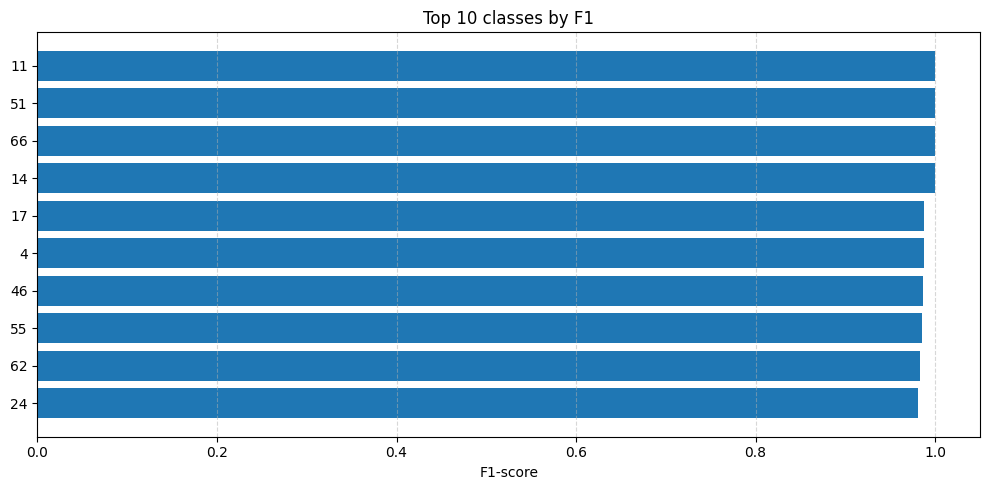

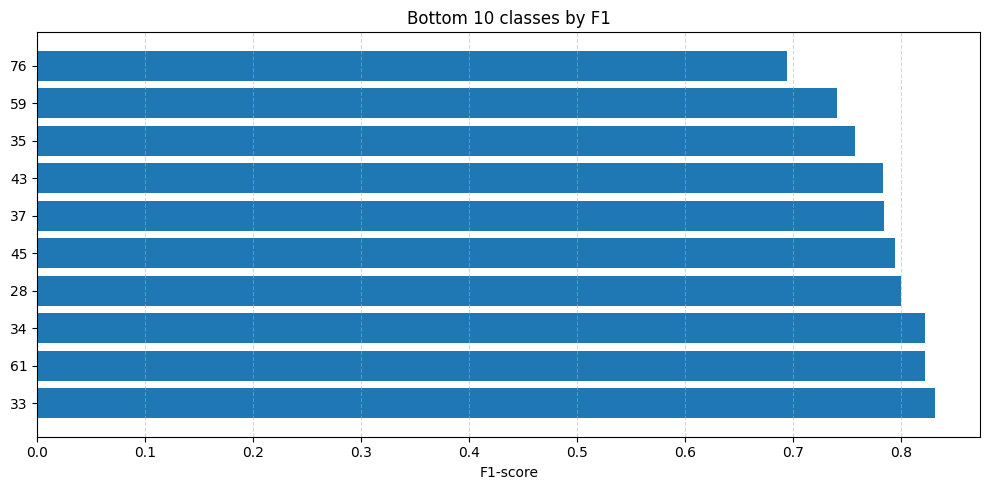

In [28]:
# --- per-class F1 상위/하위 k개 추출용 ---
report_dict = classification_report(
    yt,
    yp,
    labels=class_ids,
    target_names=target_names,
    zero_division=0,
    output_dict=True,   # 딕셔너리로 받기
)

per_class_stats = []
for cid, name in zip(class_ids, target_names):
    f1 = report_dict[name]["f1-score"]
    support = report_dict[name]["support"]
    per_class_stats.append({
        "class_id": int(cid),
        "label": name,
        "f1": float(f1),
        "support": int(support),
    })

per_class_df = pd.DataFrame(per_class_stats)

# k 값은 취향대로 (예: 10개)
TOP_K = 10
BOTTOM_K = 10

top_k_df = per_class_df.sort_values("f1", ascending=False).head(TOP_K)
bottom_k_df = per_class_df.sort_values("f1", ascending=True).head(BOTTOM_K)

print("\n[Top F1 classes]")
print(top_k_df)

print("\n[Bottom F1 classes]")
print(bottom_k_df)

# --- 그래프로 시각화 (bar chart) ---

# 1) 상위 TOP_K 클래스 F1 bar chart
plt.figure(figsize=(10, 5))
plt.barh(top_k_df["label"], top_k_df["f1"])
plt.gca().invert_yaxis()  # 높은 F1이 위에 오도록
plt.xlabel("F1-score")
plt.title(f"Top {TOP_K} classes by F1")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 2) 하위 BOTTOM_K 클래스 F1 bar chart
plt.figure(figsize=(10, 5))
plt.barh(bottom_k_df["label"], bottom_k_df["f1"])
plt.gca().invert_yaxis()
plt.xlabel("F1-score")
plt.title(f"Bottom {BOTTOM_K} classes by F1")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
# --- Test inference (test.csv → 예측) ---
all_pred_idx = []

with torch.no_grad():
    for x, m, s in test_ld:   # test_ld = FlowDatasetInfer DataLoader
        x, m, s = x.to(DEVICE), m.to(DEVICE), s.to(DEVICE)
        out = model(x, s, key_padding_mask=m)
        pred = out.argmax(1).cpu().numpy()
        all_pred_idx.append(pred)

all_pred_idx = np.concatenate(all_pred_idx)
all_pred_label = le.inverse_transform(all_pred_idx)

In [30]:
# --- 예측 CSV 생성 ---
if "id" in df_test.columns:
    sub = pd.DataFrame({
        "id": df_test["id"].values,
        "label": all_pred_label,
    })
else:
    sub = pd.DataFrame({
        "id": np.arange(len(df_test)),
        "label": all_pred_label,
    })

In [31]:
# 파일 이름은 취향대로 바꿔도 됨 (예: "예측_데이터.csv")
sub.to_csv("prediction.csv", index=False)
print("\nSaved prediction.csv")


Saved prediction.csv


In [32]:
# --- best 모델 저장 ---
if best_state is not None:
    torch.save(best_state, "best_model1.pth")
else:
    torch.save(model.state_dict(), "best_model1.pth")
print("Saved best_model1.pth")

Saved best_model1.pth
